In [1]:
import pandas as pd

from matplotlib import pyplot as plt
import matplotlib.lines as mlines

In [4]:
policies = ["ee_nobatch", "off","eager", "lazy", "median", "average", "rebatching"]
throughputs = []
rougeL_scores = []
bert_scores = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/layer_50_conf_0.7/req_100_batch_1_layer_50_conf_0.7_eager_copy.csv")
throughputs.append(ee_df.throughput.mean())
rougeL_scores.append(ee_df.rougeL.mean())
bert_scores.append(ee_df.bert_score.mean())
for policy in policies[1:]:
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/layer_50_conf_0.7/req_100_batch_4_layer_50_conf_0.7_{policy}_copy.csv")
    throughputs.append(df.throughput.mean())
    rougeL_scores.append(df.rougeL.mean())
    bert_scores.append(df.bert_score.mean())
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "rougeL": rougeL_scores,
    "bert_score": bert_scores
})
df

,policy,throughput,rougeL,bert_score
0,ee_nobatch,26.285305,0.103029,0.797522
1,off,72.156158,0.092253,0.818728
2,eager,106.051441,0.013382,0.717568
3,lazy,74.402421,0.081500,0.814817
4,median,94.819489,0.020611,0.730032
5,average,75.405770,0.078294,0.811849
6,rebatching,79.956550,0.064661,0.786699


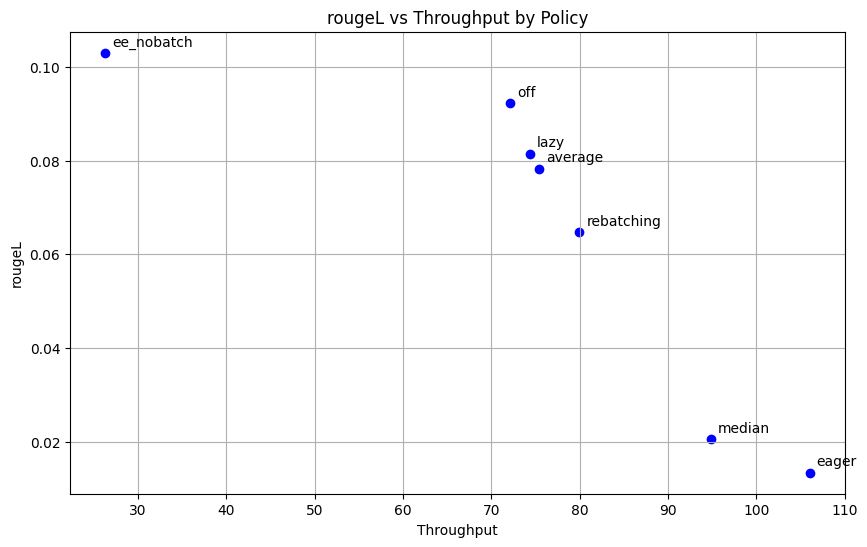

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df['throughput'], df['rougeL'], color='b')

# Annotate each point with the policy name
for i, row in df.iterrows():
    plt.annotate(row['policy'], (row['throughput'], row['rougeL']), textcoords="offset points", xytext=(5,5), ha='left')

plt.xlabel('Throughput')
plt.ylabel('rougeL')
plt.title('rougeL vs Throughput by Policy')
plt.grid(True)
plt.show()


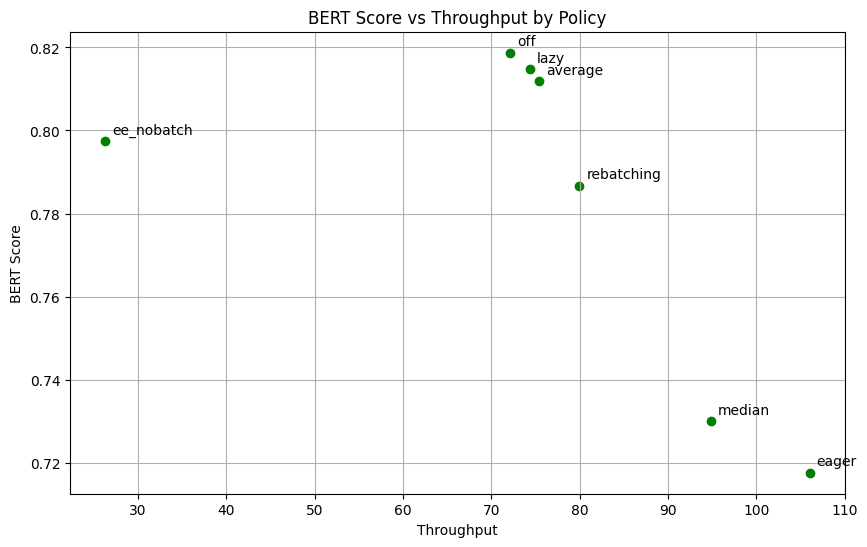

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(df['throughput'], df['bert_score'], color='g')

# Annotate each point with the policy name
for i, row in df.iterrows():
    plt.annotate(row['policy'], (row['throughput'], row['bert_score']), textcoords="offset points", xytext=(5,5), ha='left')

plt.xlabel('Throughput')
plt.ylabel('BERT Score')
plt.title('BERT Score vs Throughput by Policy')
plt.grid(True)
plt.show()
